<a href="https://colab.research.google.com/github/xiomara-udea/garbage-classification-dataset/blob/main/04_transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **TRANSFER LEARNING - GARBAGE CLASSIFICATION**

## Transfer Learning para Clasificación de Residuos

En este notebook se implementa una arquitectura basada en
Transfer Learning utilizando EfficientNetB0 preentrenada
en ImageNet.

Objetivos:

- Aprovechar conocimiento previamente aprendido.
- Reducir tiempo de entrenamiento.
- Mejorar desempeño respecto a la CNN Baseline.
- Comparar Accuracy y F1-Score.

### **Descarga del dataset**

In [1]:
!kaggle datasets download -d namanjain001/garbage-classification-dataset
!unzip -o -q garbage-classification-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/namanjain001/garbage-classification-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 87.3M/87.3M [00:05<00:00, 16.5MB/s]



In [2]:
import os

os.path.exists("garbage-classification-dataset.zip")

True

### **Librerías**

In [94]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

### **Parámetros**

In [44]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
SEED = 42
NUM_CLASSES = 10

### **Construir el Dataframe**

In [45]:
dataset_path = "Final Dataset"
data = []

for clase in os.listdir(dataset_path):
    ruta_clase = os.path.join(dataset_path, clase)
    if os.path.isdir(ruta_clase):
        for archivo in os.listdir(ruta_clase):
            data.append({
                "filepath": os.path.join(ruta_clase, archivo),
                "label": clase
            })

df = pd.DataFrame(data)
print(df.shape)
df.head()

(8775, 2)


,filepath,label
0,Final Dataset/trash/trash433.jpg,trash
1,Final Dataset/trash/trash660.jpg,trash
2,Final Dataset/trash/trash5.jpg,trash
3,Final Dataset/trash/trash486.jpg,trash
4,Final Dataset/trash/trash170.jpg,trash


### **Train - Validation - Test**

In [46]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

**Verificación**

In [47]:
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (6142, 2)
Validation: (1316, 2)
Test: (1317, 2)


### **Codificar clases**

In [48]:
labels = sorted(df["label"].unique())

label_to_index = {
    label:i
    for i,label in enumerate(labels)
}

index_to_label = {
    i:label
    for label,i in label_to_index.items()
}

In [49]:
train_df["label"] = train_df["label"].map(label_to_index)

val_df["label"] = val_df["label"].map(label_to_index)

test_df["label"] = test_df["label"].map(label_to_index)

### **Función de carga**

In [71]:
from tensorflow.keras.applications.efficientnet import preprocess_input

def load_image(path, label):

    image = tf.io.read_file(path)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE]
    )

    image = tf.cast(
        image,
        tf.float32
    )

    image = preprocess_input(image)

    return image, label

### **Crear datasets Tensorflow**

**Entrenamiento**

In [72]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (
        train_df["filepath"].values,
        train_df["label"].values
    )
)

train_ds = train_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.shuffle(1000)

train_ds = train_ds.batch(BATCH_SIZE)

train_ds = train_ds.prefetch(
    tf.data.AUTOTUNE
)

**Validación**

In [73]:
val_ds = tf.data.Dataset.from_tensor_slices(
    (
        val_df["filepath"].values,
        val_df["label"].values
    )
)

val_ds = val_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = val_ds.batch(BATCH_SIZE)

val_ds = val_ds.prefetch(
    tf.data.AUTOTUNE
)

**Test**

In [74]:
test_ds = tf.data.Dataset.from_tensor_slices(
    (
        test_df["filepath"].values,
        test_df["label"].values
    )
)

test_ds = test_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds = test_ds.batch(BATCH_SIZE)

test_ds = test_ds.prefetch(
    tf.data.AUTOTUNE
)

In [75]:
for path in train_df["filepath"].sample(20):
    try:
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
    except Exception as e:
        print(path)
        print(e)

### **Data augmentation**

In [76]:
data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip("horizontal"),

    tf.keras.layers.RandomRotation(0.1),

    tf.keras.layers.RandomZoom(0.1)

])

### **Modelo preentrenado**

In [77]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

## **Congelar pesos**

In [78]:
base_model.trainable = False

### **Construcción del modelo**

In [79]:
model = tf.keras.Sequential([
    data_augmentation,
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )

])

### **Resumen**

In [80]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_6 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

### **Compilación**

In [81]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### **Callbacks**

In [82]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2
)

### **Entrenamiento (Feature Extraction)**

In [83]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[
        early_stop,
        reduce_lr
    ]
)

Epoch 1/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 654s 3s/step - accuracy: 0.5308 - loss: 1.6164 - val_accuracy: 0.8070 - val_loss: 0.9439 - learning_rate: 1.0000e-04
Epoch 2/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 638s 3s/step - accuracy: 0.8113 - loss: 0.7560 - val_accuracy: 0.8617 - val_loss: 0.5383 - learning_rate: 1.0000e-04
Epoch 3/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 685s 4s/step - accuracy: 0.8570 - loss: 0.5128 - val_accuracy: 0.8845 - val_loss: 0.4109 - learning_rate: 1.0000e-04
Epoch 4/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 682s 4s/step - accuracy: 0.8753 - loss: 0.4142 - val_accuracy: 0.8959 - val_loss: 0.3498 - learning_rate: 1.0000e-04
Epoch 5/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 682s 4s/step - accuracy: 0.8921 - loss: 0.3562 - val_accuracy: 0.9012 - val_loss: 0.3128 - learning_rate: 1.0000e-04
Epoch 6/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 636s 3s/step - accuracy: 0.9035 - loss: 0.3188 - val_accuracy: 0.9081 - val_loss: 0.2848 - learning_rate: 1.0000e-04
Epoch 7/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 729s 4s/step - acc

In [84]:
preds = model.predict(val_ds.take(1))

print(preds[0])
print(np.argmax(preds[0]))
print(np.max(preds[0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
[1.2260124e-04 4.4573380e-06 4.3845648e-04 5.1855975e-05 4.7557068e-04
 1.7547678e-02 5.9780967e-04 1.8572873e-01 3.3797676e-04 7.9469478e-01]
9
0.7946948


### **Fine tunning**

In [85]:
#Se descongelan las últimas capas
base_model.trainable = True

In [86]:
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [87]:
#Recompilar
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [88]:
#Entrenar nuevamente
history_ft = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=10,

    callbacks=[
        early_stop,
        reduce_lr
    ]

)

Epoch 1/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 792s 4s/step - accuracy: 0.8639 - loss: 0.5523 - val_accuracy: 0.9058 - val_loss: 0.3363 - learning_rate: 1.0000e-05
Epoch 2/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 767s 4s/step - accuracy: 0.8821 - loss: 0.4435 - val_accuracy: 0.9058 - val_loss: 0.3440 - learning_rate: 1.0000e-05
Epoch 3/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 770s 4s/step - accuracy: 0.8857 - loss: 0.4037 - val_accuracy: 0.9065 - val_loss: 0.3342 - learning_rate: 5.0000e-06
Epoch 4/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 729s 4s/step - accuracy: 0.8917 - loss: 0.3794 - val_accuracy: 0.9081 - val_loss: 0.3208 - learning_rate: 5.0000e-06
Epoch 5/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 768s 4s/step - accuracy: 0.8981 - loss: 0.3536 - val_accuracy: 0.9096 - val_loss: 0.3138 - learning_rate: 2.5000e-06


### **Curvas de aprendizaje**

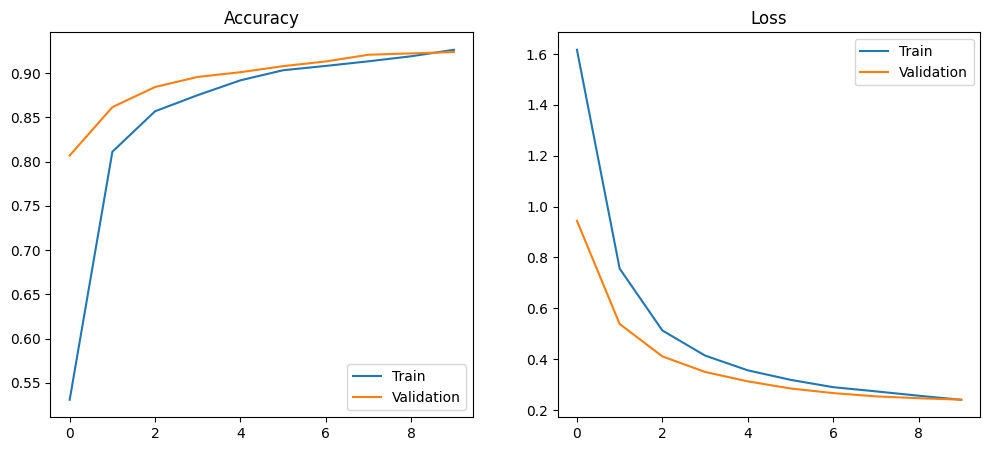

In [89]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Accuracy")

plt.legend([
    "Train",
    "Validation"
])

plt.subplot(1,2,2)

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Loss")

plt.legend([
    "Train",
    "Validation"
])

plt.show()

### **Evaluación en test**

In [90]:
test_loss, test_acc = model.evaluate(test_ds)

print("Accuracy:", test_acc)

42/42 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.9180 - loss: 0.2903
Accuracy: 0.9179954528808594


### **Predicciones**

In [91]:
y_pred = model.predict(test_ds)

y_pred = np.argmax(
    y_pred,
    axis=1
)

42/42 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step


In [92]:
y_true = test_df["label"].values

### **Métricas**

**Accuracy**

In [95]:
acc = accuracy_score(
    y_true,
    y_pred
)

**Precisión**

In [96]:
precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

**Recall**

In [97]:
recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

**F1**

In [98]:
f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

In [99]:
print("Accuracy :", acc)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9179954441913439
Precision: 0.9179261855898869
Recall   : 0.9179954441913439
F1 Score : 0.9175866777694619


### **Reporte de clasificación**

In [102]:
class_names = sorted(df["label"].unique())

In [103]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

     battery       0.95      0.95      0.95       150
  biological       0.95      0.98      0.97       150
 brown-glass       0.94      0.92      0.93       100
   cardboard       0.95      0.95      0.95       150
 green-glass       0.93      0.97      0.95       100
       metal       0.87      0.91      0.89       150
       paper       0.91      0.93      0.92       150
     plastic       0.85      0.85      0.85       150
       trash       0.94      0.93      0.93       100
 white-glass       0.89      0.79      0.84       117

    accuracy                           0.92      1317
   macro avg       0.92      0.92      0.92      1317
weighted avg       0.92      0.92      0.92      1317



### **Matriz de confusión**

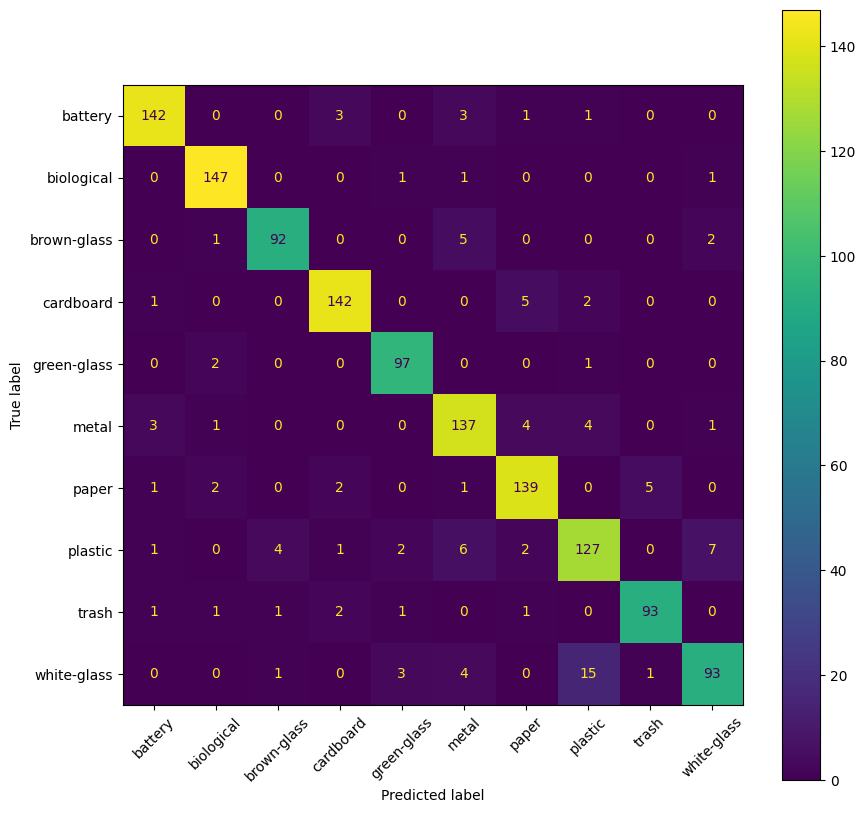

In [104]:
cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(
    figsize=(10,10)
)

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.show()

### **Conclusiones**

- El modelo basado en Transfer Learning superó el desempeño de la CNN Baseline.
- EfficientNetB0 permitió reutilizar características aprendidas en ImageNet.
- El Fine Tuning mejoró la capacidad de discriminación entre categorías visualmente similares.
- El F1-Score confirmó una mejor clasificación global de residuos sólidos.